In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Defino métrica de nitidez del paper: (

def frequency_domain_image_blur_measurement(image):
    """
    Calcula la métrica FM propuesta en:
    'Image Sharpness Measure for Blurred Images in Frequency Domain'.

    Entrada:
        image: imagen en escala de grises o RGB/BGR.

    Salida:
        FM: medida de nitidez en dominio frecuencial.
    """

    # Si la imagen es RGB/BGR, convertir a escala de grises
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    gray = gray.astype(np.float32)

    # Paso 1: Calcular la Transformada de Fourier de la imagen
    F = np.fft.fft2(gray)

    # Paso 2: centrar el espectro
    Fc = np.fft.fftshift(F)

    # Paso 3: magnitud del espectro
    AF = np.abs(Fc)

    # Paso 4: calcular el máximo de la magnitud del espectro
    max_AF = np.max(AF)

    # Paso 5: calcular threshold
    threshold = max_AF/1000

    # Componentes por encima del threshold
    TH = np.sum(AF > threshold)

    # Paso 6: calcular la métrica FM
    M, N = gray.shape
    FM = TH / (M * N)

    return FM

In [3]:
def roi_central(frame, area_ratio=0.10):
    """
    Extrae una ROI cuadrada centrada exactamente en el centro de la imagen.
    El área de la ROI representa aproximadamente area_ratio del área total.
    """

    if frame is None:
        raise ValueError("El frame recibido es None.")

    h, w = frame.shape[:2]

    # Área deseada de la ROI
    roi_area = area_ratio * h * w

    # Como la ROI es cuadrada: lado^2 = área
    side = int(np.sqrt(roi_area))

    # No puede superar el tamaño de la imagen
    side = min(side, h, w)

    # Centro exacto de la imagen
    cx = w // 2
    cy = h // 2

    # Coordenadas de la ROI centrada
    x1 = cx - side // 2
    y1 = cy - side // 2
    x2 = x1 + side
    y2 = y1 + side

    roi = frame[y1:y2, x1:x2]

    return roi, (x1, y1, x2, y2)

In [4]:
def detectar_maximo_enfoque(
        video_path,
        area_ratio=0.10,
        guardar_frames=True
):
    """
    Algoritmo completo de detección automática de máximo enfoque.

    Para cada frame del video:
        1. Calcula la métrica FM sobre el frame completo.
        2. Extrae una ROI central.
        3. Calcula la métrica FM sobre la ROI.
        4. Guarda la evolución frame a frame.

    Luego:
        5. Detecta automáticamente el frame de máximo enfoque.
        6. Devuelve resultados, curvas, frames y visualizaciones auxiliares.
    """

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError("No se pudo abrir el video. Revisá el path o el nombre del archivo.")

    frames = []
    fm_full = []
    fm_roi = []
    roi_coords_per_frame = []

    frame_idx = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame is None:
            print(f"Advertencia: No se pudo leer el frame {frame_idx}. Se omite.")
            continue

        # guardar frame original
        if guardar_frames:
            frames.append(frame)

        # Métrica FM sobre el frame completo
        fm_full_value = frequency_domain_image_blur_measurement(frame)
        fm_full.append(fm_full_value)

        # ROI central y métrica FM sobre la ROI
        roi_img, roi_coords = roi_central(frame, area_ratio=area_ratio)
        fm_roi_value = frequency_domain_image_blur_measurement(roi_img)
        fm_roi.append(fm_roi_value)

        roi_coords_per_frame.append(roi_coords)

        frame_idx += 1

    cap.release()
    fm_full = np.array(fm_full)
    fm_roi = np.array(fm_roi)

    if len(fm_full) == 0:
        raise ValueError("No se procesó ningún frame del video.")
    
    # Detección automática del máximo enfoque
    best_frame_full_idx = int(np.argmax(fm_full))
    best_frame_roi_idx = int(np.argmax(fm_roi))

    best_fm_full = float(fm_full[best_frame_full_idx])
    best_fm_roi = float(fm_roi[best_frame_roi_idx])

    resultado = {
        "video_path": video_path,
        "area_ratio": area_ratio,
        "num_frames": len(fm_full),

        "fm_full": fm_full,
        "fm_roi": fm_roi,

        "best_frame_full_idx": best_frame_full_idx,
        "best_frame_roi_idx": best_frame_roi_idx,

        "best_fm_full": best_fm_full,
        "best_fm_roi": best_fm_roi,

        "roi_coords_per_frame": roi_coords_per_frame,
    }

    if guardar_frames:
        best_frame_full = frames[best_frame_full_idx].copy()
        best_frame_roi = frames[best_frame_roi_idx].copy()

        # ROI sobre el frame de máximo enfoque según ROI
        roi_best, roi_coords_best = roi_central(
            best_frame_roi,
            area_ratio=area_ratio
        )

        # Frame con rectángulo de ROI
        frame_roi_vis = best_frame_roi.copy()
        x1, y1, x2, y2 = roi_coords_best

        cv2.rectangle(
            frame_roi_vis,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )


        resultado.update({
            "frames": frames,
            "best_frame_full": best_frame_full,
            "best_frame_roi": best_frame_roi,
            "roi_best": roi_best,
            "roi_coords_best": roi_coords_best,
            "frame_roi_vis": frame_roi_vis
        })

    return resultado


In [5]:
video_path = "focus_video.mov"

resultado = detectar_maximo_enfoque(
    video_path=video_path,
    area_ratio=0.10
)
print("Cantidad de frames procesados:", resultado["num_frames"])

print("Máximo enfoque usando frame completo:")
print("Frame:", resultado["best_frame_full_idx"])
print("FM:", resultado["best_fm_full"])

print()

print("Máximo enfoque usando ROI central:")
print("Frame:", resultado["best_frame_roi_idx"])
print("FM:", resultado["best_fm_roi"])

Cantidad de frames procesados: 171
Máximo enfoque usando frame completo:
Frame: 109
FM: 0.028624131944444443

Máximo enfoque usando ROI central:
Frame: 111
FM: 0.3473970439892987


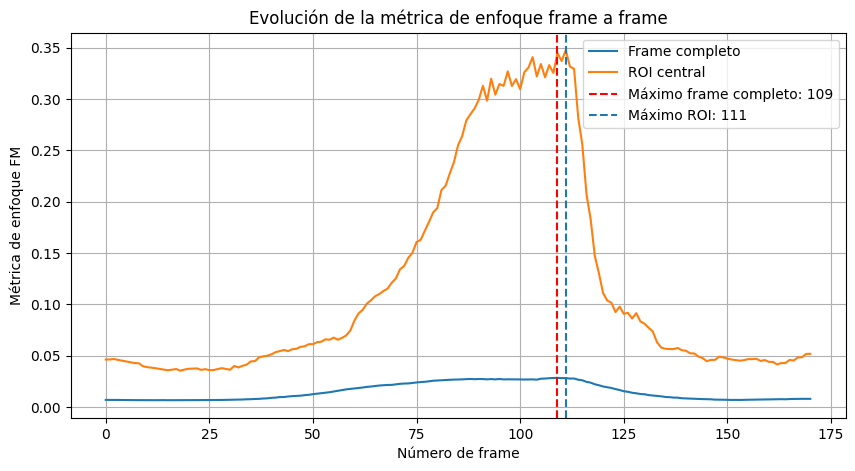

In [6]:
fm_full = resultado["fm_full"]
fm_roi = resultado["fm_roi"]

best_frame_full_idx = resultado["best_frame_full_idx"]
best_frame_roi_idx = resultado["best_frame_roi_idx"]

plt.figure(figsize=(10, 5))

plt.plot(fm_full, label="Frame completo")
plt.plot(fm_roi, label="ROI central")

plt.axvline(
    best_frame_full_idx,
    linestyle="--",
    label=f"Máximo frame completo: {best_frame_full_idx}",
    color="red"
)
    
plt.axvline(
    best_frame_roi_idx,
    linestyle="--",
    label=f"Máximo ROI: {best_frame_roi_idx}"
)

plt.xlabel("Número de frame")
plt.ylabel("Métrica de enfoque FM")
plt.title("Evolución de la métrica de enfoque frame a frame")
plt.legend()
plt.grid(True)
plt.show()

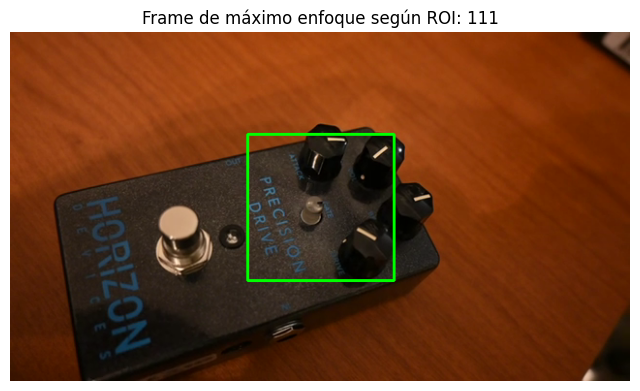

In [7]:
frame_roi_vis_rgb = cv2.cvtColor(
    resultado["frame_roi_vis"],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 5))
plt.imshow(frame_roi_vis_rgb)
plt.title(f"Frame de máximo enfoque según ROI: {resultado['best_frame_roi_idx']}")
plt.axis("off")
# plt.grid()
plt.show()

## Unsharp marking 


In [8]:
def unsharp_masking(image, kernel_size=(5, 5), sigma=1.0, amount=1.5):
    """
    Aplica unsharp masking para realzar bordes y detalles.
    """

    if image is None:
        raise ValueError("La imagen recibida es None.")

    blurred = cv2.GaussianBlur(image, kernel_size, sigma)

    sharpened = cv2.addWeighted(
        image,        # f(x,y)
        1 + amount,  # (1 + k)
        blurred,     # f_s(x,y)
        -amount,     # -k
        0
    )

    # g(x,y) = f(x,y) + k * (f(x,y) - f_s(x,y))
    # k -> amount
    
    return sharpened

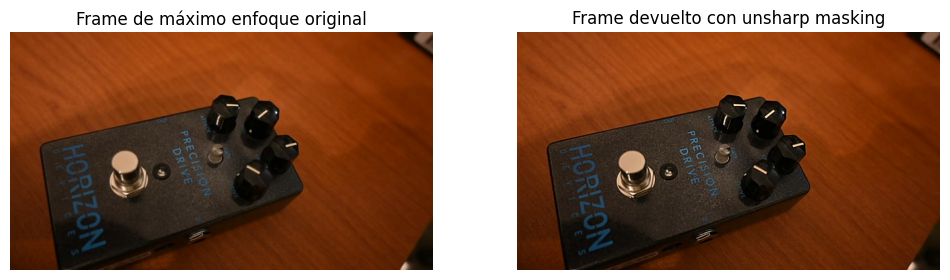

In [9]:
# Tomamos el frame de máximo enfoque detectado automáticamente
best_frame = resultado["best_frame_roi"].copy()

# Aplicamos unsharp masking para realzar la zona enfocada (amount = 1)
best_frame_unsharp = unsharp_masking(
    best_frame,
    kernel_size=(5, 5),
    sigma=1.0,
    amount=1
)

# Mostramos original vs resultado
best_frame_rgb = cv2.cvtColor(best_frame, cv2.COLOR_BGR2RGB)
best_frame_unsharp_rgb = cv2.cvtColor(best_frame_unsharp, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(best_frame_rgb)
plt.title("Frame de máximo enfoque original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(best_frame_unsharp_rgb)
plt.title("Frame devuelto con unsharp masking")
plt.axis("off")

plt.show()

In [10]:
cv2.imwrite("frame_maximo_enfoque_original.png", best_frame)
cv2.imwrite("frame_maximo_enfoque_roi.png", resultado["frame_roi_vis"])
cv2.imwrite("frame_maximo_enfoque_unsharp.png", best_frame_unsharp)

True

El algoritmo implementado calcula la métrica FM para cada frame del video, tanto sobre el frame completo como sobre una ROI central cuadrada equivalente al 10% del área total. Luego, el punto de máximo enfoque se obtiene automáticamente mediante `np.argmax`, seleccionando el frame con mayor valor de FM. Finalmente, sobre el frame detectado se aplica unsharp masking para realzar los bordes y devolver una versión visualmente más nítida.

## Verificación

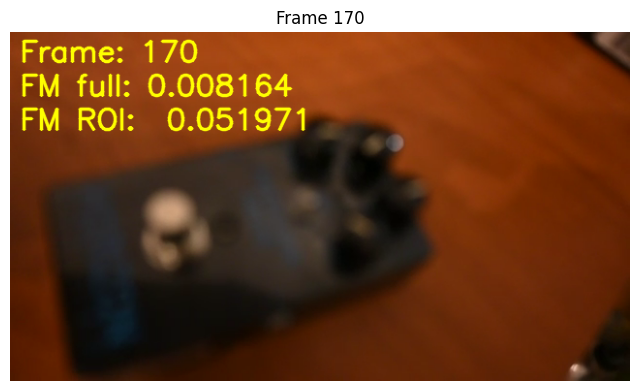

In [11]:
import time
from IPython.display import display, clear_output

cap = cv2.VideoCapture(video_path)

fig, ax = plt.subplots(figsize=(8, 5))
plt.ion()

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Número de frame en el frame
    cv2.putText(
        frame_rgb,
        f"Frame: {frame_idx}",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )

    # Número de frame en el frame
    cv2.putText(
        frame_rgb,
        f"FM full: {fm_full[frame_idx]:.6f}",
        (10, 65),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )

    # Número de frame en el frame
    cv2.putText(
        frame_rgb,
        f"FM ROI:  {fm_roi[frame_idx]:.6f}",
        (10, 100),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )
    ax.clear()
    ax.imshow(frame_rgb)
    ax.set_title(f"Frame {frame_idx}")
    ax.axis("off")

    clear_output(wait=True)
    display(fig)

    time.sleep(0.1)  
    frame_idx += 1

cap.release()
plt.ioff()
plt.close(fig)